In [1]:
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision, numpy as np, cv2, matplotlib.pyplot as plt
from torchvision import transforms
from torchvision.utils import make_grid
from tqdm import tqdm
import math, numpy as np
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

c:\Users\mike8\anaconda3\envs\pytorch\Lib\site-packages\torch\onnx\_internal\_beartype.py:36: UserWarning: module 'beartype.roar' has no attribute 'BeartypeDecorHintPep585DeprecationWarning'
  warnings.warn(f"{e}")


Device: cuda


In [2]:
from dataclasses import dataclass
@dataclass
class Config:
    dataset: str = "CELEBA"
    image_size: int = 32
    channels: int = 1
    batch_size: int = 128
    epochs_baseline: int = 500
    epochs_wtmk: int = 500
    num_workers: int = 2
    lr: float = 2e-4
    T: int = 1000
    beta_start: float = 1e-4
    beta_end: float = 2e-2
    gamma: float = 0.8
    tA_frac: float = 0.5
    use_f1_zero: bool = True
    wtmk_shape: str = "square"
    wtmk_pos: str = "bottom_right"
    wtmk_size: int = 8
    wtmk_margin: int = 2
    n_final_samples: int = 36
    verify_batches: int = 8
    verify_batch_size: int = 64
cfg = Config()
print(cfg)


Config(dataset='CELEBA', image_size=32, channels=1, batch_size=128, epochs_baseline=500, epochs_wtmk=500, num_workers=2, lr=0.0002, T=1000, beta_start=0.0001, beta_end=0.02, gamma=0.8, tA_frac=0.5, use_f1_zero=True, wtmk_shape='square', wtmk_pos='bottom_right', wtmk_size=8, wtmk_margin=2, n_final_samples=36, verify_batches=8, verify_batch_size=64)


In [3]:

if cfg.dataset.upper() == "MNIST":
    mean, std = (0.5,), (0.5,)
    transform = transforms.Compose([
        transforms.Resize(cfg.image_size),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])
    trainset = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=transform)
elif cfg.dataset.upper() == "CIFAR10":
    cfg.channels = 3
    mean, std = (0.5, 0.5, 0.5), (0.5, 0.5, 0.5)
    transform = transforms.Compose([
        transforms.Resize(cfg.image_size),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])
    trainset = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
elif cfg.dataset.upper() == "CELEBA":
    cfg.channels = 3
    mean, std = (0.5, 0.5, 0.5), (0.5, 0.5, 0.5)
    transform = transforms.Compose([
        transforms.CenterCrop(140),
        transforms.Resize(cfg.image_size),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])
    trainset = torchvision.datasets.CelebA(root="./data", split="train", download=True, transform=transform)
else:
    raise ValueError("Unsupported dataset")
subset_size = 5000
indices = np.random.choice(len(trainset), size=min(subset_size, len(trainset)), replace=False)
train_loader = DataLoader(trainset, batch_size=cfg.batch_size, shuffle=True, num_workers=cfg.num_workers, pin_memory=True)
print("Train batches:", len(train_loader))


Files already downloaded and verified
Train batches: 1272


In [4]:

def make_beta_schedule(T, beta_start, beta_end):
    return torch.linspace(beta_start, beta_end, T)

class DiffusionSchedule:
    def __init__(self, T, beta_start, beta_end, device):
        self.T = T
        self.device = device
        self.beta = make_beta_schedule(T, beta_start, beta_end).to(device)
        self.alpha = 1.0 - self.beta
        self.alpha_bar = torch.cumprod(self.alpha, dim=0)
    def q_sample(self, x0, t, eps=None):
        if eps is None:
            eps = torch.randn_like(x0)
        a_bar = self.alpha_bar[t].view(-1, 1, 1, 1)
        return a_bar.sqrt()*x0 + (1.0 - a_bar).sqrt()*eps, eps

sched = DiffusionSchedule(cfg.T, cfg.beta_start, cfg.beta_end, device)
print("Schedule ready.")


Schedule ready.


In [5]:
class TinyUNet(nn.Module):
    def __init__(self, in_ch=1, ch=64):
        super().__init__()
        self.time_embed = nn.Sequential(
            nn.Linear(128, 128), nn.SiLU(), nn.Linear(128, 128)
        )
        self.in_conv = nn.Conv2d(in_ch, ch, 3, padding=1)
        self.down = nn.Conv2d(ch, ch * 2, 4, 2, 1)
        self.mid = nn.Conv2d(ch * 2, ch * 2, 3, padding=1)
        self.up = nn.ConvTranspose2d(ch * 2, ch, 4, 2, 1)
        self.out = nn.Conv2d(ch, in_ch, 3, padding=1)

    def timestep_embedding(self, t, dim=128, max_period=10000):
        half = dim // 2
        freqs = torch.exp(
            -math.log(max_period)
            * torch.arange(0, half, device=t.device).float()
            / half
        )
        args = t.float()[:, None] * freqs[None]
        emb = torch.cat([torch.cos(args), torch.sin(args)], dim=-1)
        if dim % 2:
            emb = torch.cat([emb, torch.zeros_like(emb[:, :1])], dim=-1)
        return emb

    def forward(self, x, t):
        temb = self.time_embed(self.timestep_embedding(t))
        h = torch.relu(self.in_conv(x))
        h = torch.relu(self.down(h))
        h = torch.relu(self.mid(h) + temb[:, :, None, None])
        h = torch.relu(self.up(h))
        return self.out(h)


model_base = TinyUNet(in_ch=cfg.channels).to(device)
model_wtmk = TinyUNet(in_ch=cfg.channels).to(device)
print("Models ready.")

Models ready.


In [6]:
def sample_timesteps(batch, T, device):
    return torch.randint(0, T, (batch,), device=device, dtype=torch.long)

def train_baseline(model, loader, sched, epochs=1, lr=2e-4):
    model.train()
    opt = torch.optim.AdamW(model.parameters(), lr=lr)
    for ep in range(epochs):
        for x0, _ in tqdm(loader, desc=f"Baseline E{ep+1}/{epochs}"):
            x0 = x0.to(device)
            b = x0.size(0)
            t = sample_timesteps(b, sched.T, device)
            x_t, eps = sched.q_sample(x0, t)
            pred = model(x_t, t)
            loss = F.mse_loss(pred, eps)
            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()
    return model


In [7]:
model_base = train_baseline(model_base, train_loader, sched, epochs=cfg.epochs_baseline)
torch.save(model_base.state_dict(), "baseline_ddpm.pth")

Baseline E500/500: 100%|██████████| 1272/1272 [00:51<00:00, 24.57it/s]


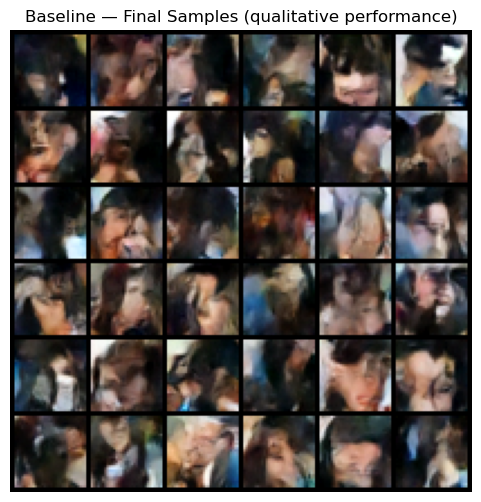

c:\Users\mike8\anaconda3\envs\pytorch\Lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: Metric `InceptionScore` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)  # noqa: B028


[Baseline] Inception Score: 1.079 ± 0.006


KeyboardInterrupt: 

In [8]:
# --- Baseline: qualitative performance & (optional) quick metrics ---

import math, torch, numpy as np
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

# If these helpers already exist earlier in your notebook, you can skip (or re-def is fine).
@torch.no_grad()
def p_mean_variance(eps_pred, x_t, t, beta, alpha, alpha_bar):
    a_t = alpha[t].view(-1,1,1,1)
    a_bar_t = alpha_bar[t].view(-1,1,1,1)
    beta_t = beta[t].view(-1,1,1,1)
    eps = eps_pred
    x0_hat = (x_t - (1 - a_t).sqrt() * eps) / a_t.sqrt()
    mean = ( (1.0/ a_t.sqrt()) * x_t - ((1 - a_t)/ (1 - a_bar_t).sqrt()) * eps )
    # safe var (t>0); when t==0 we won't sample noise anyway
    var = torch.where(
        (t[:, None, None, None] > 0),
        beta_t * (1 - alpha_bar[t-1].view(-1,1,1,1)) / (1 - a_bar_t + 1e-8),
        torch.zeros_like(beta_t),
    )
    return mean, var, x0_hat

@torch.no_grad()
def sample_images(model, sched, n=36, gamma_div=None):
    model.eval()
    x_t = torch.randn(n, cfg.channels, cfg.image_size, cfg.image_size, device=next(model.parameters()).device)
    for t_step in reversed(range(sched.T)):
        t = torch.full((n,), t_step, device=x_t.device, dtype=torch.long)
        eps_pred = model(x_t, t)
        if t_step > 0:
            mean, var, _ = p_mean_variance(eps_pred, x_t, t, sched.beta, sched.alpha, sched.alpha_bar)
            x_t = mean + var.sqrt() * torch.randn_like(x_t)
        else:
            _, _, x0_hat = p_mean_variance(eps_pred, x_t, t, sched.beta, sched.alpha, sched.alpha_bar)
            x_t = x0_hat
    if gamma_div:  # not needed for baseline; useful for f1=0 trick on watermarked model
        x_t = x_t / gamma_div
    imgs = (x_t.clamp(-1,1) + 1) * 0.5  # [0,1]
    return imgs

def show_grid(imgs, title="", save_path=None):
    grid = make_grid(imgs, nrow=int(math.sqrt(len(imgs))), padding=2)
    npimg = grid.detach().cpu().permute(1,2,0).numpy()
    plt.figure(figsize=(6,6))
    plt.imshow(npimg.squeeze() if npimg.shape[-1]==1 else npimg)
    plt.axis("off"); plt.title(title); plt.show()
    if save_path:
        import imageio
        arr = (npimg*255).astype(np.uint8)
        if arr.ndim==2: imageio.imwrite(save_path, arr)
        else: imageio.imwrite(save_path, arr)

# 1) Generate and display baseline samples
imgs_base = sample_images(model_base, sched, n=cfg.n_final_samples)
show_grid(imgs_base, "Baseline — Final Samples (qualitative performance)")

# 2) (Optional) quick metrics: IS/FID (RGB only; small-sample & indicative)
# --- Fixed IS/FID block for torchmetrics expecting uint8 images ---

# --- Robust IS/FID for various torchmetrics versions (expects uint8 RGB) ---

try:
    from torchmetrics.image.inception import InceptionScore
    from torchmetrics.image.fid import FrechetInceptionDistance
    TM_OK = True
except Exception:
    TM_OK = False
    print("torchmetrics not available; skipping IS/FID.")

def to_uint8_3ch(x: torch.Tensor) -> torch.Tensor:
    # x: [N, C, H, W] float in [0,1]
    x = (x.clamp(0,1) * 255).to(torch.uint8)
    if x.size(1) == 1:
        x = x.repeat(1, 3, 1, 1)
    return x

if TM_OK and cfg.channels == 3 and cfg.image_size >= 32:
    @torch.no_grad()
    def gather_samples(model, total=1000, bs=64):
        outs = []
        for _ in range((total + bs - 1)//bs):
            outs.append(sample_images(model, sched, n=bs).cpu())
        return torch.cat(outs, dim=0)[:total]  # float [0,1]

    gen_base = gather_samples(model_base, total=1000)
    gen_base_u8 = to_uint8_3ch(gen_base)

    # Inception Score (use update/compute to avoid tuple-from-forward issues)
    is_metric = InceptionScore(feature=2048).to(gen_base_u8.device)
    is_metric.update(gen_base_u8)                  # accepts uint8 RGB
    is_mean, is_std = is_metric.compute()          # returns (mean, std)
    print(f"[Baseline] Inception Score: {is_mean.item():.3f} ± {is_std.item():.3f}")

    # FID (placeholder: self vs self; proper FID needs real-data stats)
    fid = FrechetInceptionDistance(feature=2048).to(gen_base_u8.device)
    fid.update(gen_base_u8, real=True)
    fid.update(gen_base_u8, real=False)
    print(f"[Baseline] FID (self vs self): {fid.compute().item():.3f}")
else:
    print("Skip metrics: need torchmetrics + RGB 3×32×32 (e.g., CIFAR-10).")



In [ ]:
def make_watermark_mask(H,W,size=8,margin=2,channels=1):
    mask = np.zeros((H,W),dtype=np.float32)
    r0 = H - margin - size
    c0 = W - margin - size
    mask[r0:r0+size,c0:c0+size]=1.0
    if channels==1: return torch.from_numpy(mask)[None]
    else: return torch.from_numpy(mask).repeat(channels,1,1)

wmask = make_watermark_mask(cfg.image_size,cfg.image_size)
xA = (2*wmask-1).to(device)

def train_watermarked(model, loader, sched, epochs=1):
    opt = torch.optim.Adam(model.parameters(), lr=cfg.lr)
    tA = int(cfg.tA_frac*sched.T)
    for ep in range(epochs):
        for x0,_ in tqdm(loader):
            x0 = x0.to(device)
            t = sample_timesteps(x0.size(0), sched.T, device)
            eps = torch.randn_like(x0)
            a_bar = sched.alpha_bar[t].view(-1,1,1,1)
            x_t = torch.where(t[:,None,None,None]<=tA,
                              a_bar.sqrt()*x0 + cfg.gamma*(1-a_bar).sqrt()*eps + (1-cfg.gamma)*xA,
                              a_bar.sqrt()*x0 + (1-a_bar).sqrt()*eps)
            eps_target = torch.where(t[:,None,None,None]<=tA,
                                     cfg.gamma*eps+(1-cfg.gamma)*xA,
                                     eps)
            loss = F.mse_loss(model(x_t,t), eps_target)
            opt.zero_grad(); loss.backward(); opt.step()
    return model


model_wtmk.load_state_dict(torch.load("baseline_ddpm.pth"))
model_wtmk = train_watermarked(model_wtmk, train_loader, sched, epochs=cfg.epochs_wtmk)


 18%|█▊        | 224/1272 [01:07<05:15,  3.33it/s]


KeyboardInterrupt: 

In [ ]:
# --- Watermarked model: qualitative performance & watermark verification ---

# 1) Generate and display final samples
imgs_wtmk = sample_images(
    model_wtmk, 
    sched, 
    n=cfg.n_final_samples,
    gamma_div=cfg.gamma if cfg.use_f1_zero else None  # divide by gamma if using f1=0 trick
)
show_grid(imgs_wtmk, "Watermarked — Final Samples (qualitative performance)")

# 2) Visualize watermark at t_A
@torch.no_grad()
def capture_intermediate(model, sched, batch_size, tA, gamma_div=None):
    model.eval()
    x_t = torch.randn(batch_size, cfg.channels, cfg.image_size, cfg.image_size, device=device)
    x_tA = None
    for t_step in reversed(range(sched.T)):
        t = torch.full((batch_size,), t_step, device=device, dtype=torch.long)
        eps_pred = model(x_t, t)
        mean, var, x0_hat = p_mean_variance(eps_pred, x_t, t, sched.beta, sched.alpha, sched.alpha_bar)
        if t_step > 0:
            x_t = mean + var.sqrt() * torch.randn_like(x_t)
        else:
            x_t = x0_hat
        if t_step == int(tA):
            x_tA = x_t.clone()
    if gamma_div:
        if x_tA is not None: x_tA = x_tA / gamma_div
        x_t = x_t / gamma_div
    return x_tA, x_t

# capture averaged state at t_A
tA = int(cfg.tA_frac * sched.T)
x_tA, _ = capture_intermediate(
    model_wtmk, sched, batch_size=cfg.verify_batch_size, tA=tA,
    gamma_div=cfg.gamma if cfg.use_f1_zero else None
)
xavg = x_tA.mean(dim=0, keepdim=True)
xavg_img = (xavg.clamp(-1,1)+1)*0.5
show_grid(xavg_img, f"Watermarked — Average at t_A={tA}")

# 3) Verification using contour similarity
def tensor_to_uint8(img):
    img = img.detach().cpu()
    if img.min() < 0: img = (img.clamp(-1,1) + 1) * 0.5
    return (img.clamp(0,1) * 255).to(torch.uint8)

def make_pattern_image_like(mask, value=255):
    m = mask[0] if mask.dim()==3 else mask
    return (m.detach().cpu().numpy() > 0).astype(np.uint8) * value

def contour_similarity(img_u8, pattern_u8):
    img_edges = cv2.Canny(cv2.GaussianBlur(img_u8,(3,3),0), 50, 150)
    pat_edges = cv2.Canny(cv2.GaussianBlur(pattern_u8,(3,3),0), 50, 150)
    contours_img,_ = cv2.findContours(img_edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours_pat,_ = cv2.findContours(pat_edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if len(contours_img)==0 or len(contours_pat)==0: return 1e9
    return min(cv2.matchShapes(ci, cp, cv2.CONTOURS_MATCH_I1, 0.0)
               for ci in contours_img for cp in contours_pat)

def verify_watermark(model, sched, batches=8, batch_size=64, tA=None, mask=None, gamma_div=None, threshold=0.3):
    if tA is None: tA = int(cfg.tA_frac * sched.T)
    if mask is None: mask = wmask
    pattern_u8 = make_pattern_image_like(mask, value=255)
    distances = []
    for _ in tqdm(range(batches), desc="Verifying"):
        x_tA, _ = capture_intermediate(model, sched, batch_size, tA, gamma_div=gamma_div)
        xavg = x_tA.mean(dim=0, keepdim=True)
        xavg_u8 = tensor_to_uint8(xavg)[0,0].numpy()
        distances.append(contour_similarity(xavg_u8, pattern_u8))
    arr = np.array(distances, dtype=np.float32)
    success = float((arr < threshold).mean())
    return arr, success

# run verification
distances, success = verify_watermark(
    model_wtmk, sched,
    batches=cfg.verify_batches, batch_size=cfg.verify_batch_size,
    tA=tA, mask=wmask,
    gamma_div=cfg.gamma if cfg.use_f1_zero else None,
    threshold=0.3
)

print("Contour distances per batch:", distances)
print(f"Detection success rate: {success:.2f}")

plt.figure()
plt.plot(np.arange(len(distances)), distances, marker='o')
plt.axhline(0.3, linestyle='--', label='threshold')
plt.xlabel("Batch"); plt.ylabel("Contour distance (lower=better)")
plt.title("Watermark Verification at t_A")
plt.legend(); plt.show()


In [ ]:
# --- Watermarked: qualitative performance + (robust) optional IS/FID ---

# 1) Show final samples from the watermarked model
imgs_wtmk = sample_images(
    model_wtmk, 
    sched, 
    n=cfg.n_final_samples, 
    gamma_div=cfg.gamma if cfg.use_f1_zero else None  # divide by gamma if using f1=0 trick
)
show_grid(imgs_wtmk, "Watermarked — Final Samples (qualitative performance)")

# 2) Optional IS/FID (robust to torchmetrics versions). Expects uint8 RGB.
try:
    from torchmetrics.image.inception import InceptionScore
    from torchmetrics.image.fid import FrechetInceptionDistance
    TM_OK_WTMK = True
except Exception:
    TM_OK_WTMK = False
    print("torchmetrics not available; skipping IS/FID for watermarked model.")

def to_uint8_3ch(x: torch.Tensor) -> torch.Tensor:
    # x: [N, C, H, W] float in [0,1]; returns uint8 RGB
    x = (x.clamp(0,1) * 255).to(torch.uint8)
    if x.size(1) == 1:
        x = x.repeat(1, 3, 1, 1)
    return x

if TM_OK_WTMK and cfg.channels == 3 and cfg.image_size >= 32:
    @torch.no_grad()
    def gather_samples(model, total=1000, bs=64, gamma_div=None):
        outs = []
        for _ in range((total + bs - 1)//bs):
            outs.append(sample_images(model, sched, n=bs, gamma_div=gamma_div).cpu())
        return torch.cat(outs, dim=0)[:total]  # float [0,1]

    # Collect samples
    gen_wtmk = gather_samples(
        model_wtmk, 
        total=1000, 
        gamma_div=cfg.gamma if cfg.use_f1_zero else None
    )
    gen_wtmk_u8 = to_uint8_3ch(gen_wtmk)

    # Inception Score (update/compute API handles tuple-return differences)
    is_metric_w = InceptionScore(feature=2048).to(gen_wtmk_u8.device)
    is_metric_w.update(gen_wtmk_u8)
    is_mean_w, is_std_w = is_metric_w.compute()
    print(f"[Watermarked] Inception Score: {is_mean_w.item():.3f} ± {is_std_w.item():.3f}")

    # FID — if you previously computed baseline samples as `gen_base_u8`,
    # compare baseline (real=True) vs watermarked (real=False). Otherwise do self-vs-self.
    fid_w = FrechetInceptionDistance(feature=2048).to(gen_wtmk_u8.device)
    if 'gen_base_u8' in globals():
        fid_w.update(gen_base_u8, real=True)      # baseline as reference
        fid_w.update(gen_wtmk_u8, real=False)     # watermarked as generated
        print(f"[FID] Baseline vs Watermarked: {fid_w.compute().item():.3f}")
    else:
        fid_w.update(gen_wtmk_u8, real=True)
        fid_w.update(gen_wtmk_u8, real=False)
        print(f"[Watermarked] FID (self vs self): {fid_w.compute().item():.3f}")
else:
    print("Skip watermarked metrics: need torchmetrics + RGB 3×32×32 (e.g., CIFAR-10).")


In [ ]:
# Side-by-side snapshot for slides
show_grid(imgs_base, "Baseline — Final Samples")
show_grid(imgs_wtmk, "Watermarked — Final Samples")